# Decision-Focused Loan Approval System

## Introduction

Machine learning systems are increasingly used in financial services to support high-stakes decisions such as loan approvals and credit risk assessment. However, multiple models with similar predictive performance can produce substantially different decisions for the same applicants, raising concerns about fairness, explainability, and decision robustness.

This project investigates these challenges using the German Credit dataset. Multiple machine learning models were trained and compared to explore model multiplicity, disagreement analysis, explainable AI techniques, and initial recourse experiments in financial decision-making systems.

The project draws inspiration from modern research directions in decision-focused learning, explainable AI, and causal recourse for high-stakes machine learning applications.

# LAYER 1: Data understanding

## 1.1 Installing necessary packages

In [1]:
!pip install pandas numpy matplotlib scikit-learn seaborn shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------------------------- -- 524.3/555.9 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 555.9/555.9 kB 1.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



## 1.2 Reading our csv file

In [2]:
import pandas as pd


df = pd.read_csv(
    r"C:\Users\COMPUTER SERVIES BW\Documents\PhD_Projects\Decision-Focused-Loan-Approval-System\data\german.data",
    sep=" ",
    header=None
)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## 1.3 Assigning proper column names

In [3]:
columns = [
    "status_checking_account",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "number_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

df.columns = columns

df.head()

,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## 1.4 Understanding our target variable

In [4]:
df["target"].value_counts()

target
1    700
2    300
Name: count, dtype: int64

### 1.4.1 Converting our "target" column entries into ML format

In [5]:
df["target"] = df["target"].map({1: 1, 2: 0})

In [6]:
df.head()

,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


## 1.5 Checking our dataset shape

In [7]:
df.shape

(1000, 21)

## 1.6 Inspecting data types

df.info()

## 1.6 Statistical overview

In [8]:
df.describe()

,duration_months,credit_amount,installment_rate,residence_since,age,number_credits,people_liable,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.700000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


## 1.7 Checking class balance + normalizing

In [9]:
df["target"].value_counts(normalize=True)

target
1    0.7
0    0.3
Name: proportion, dtype: float64

## 1.8 Categorical vs Numerical features

In [10]:
df.dtypes

status_checking_account    object
duration_months             int64
credit_history             object
purpose                    object
credit_amount               int64
savings_account            object
employment_since           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_since             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
number_credits              int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
target                      int64
dtype: object

## 1.9 Splitting data into train/test set

In [11]:
df.isnull().sum()

status_checking_account    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
target                     0
dtype: int64

In [12]:
df.isna().sum()

status_checking_account    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
target                     0
dtype: int64

In [13]:
df.isnull().values.any()

np.False_

In [14]:
df = df.dropna()

In [15]:
df.dtypes

status_checking_account    object
duration_months             int64
credit_history             object
purpose                    object
credit_amount               int64
savings_account            object
employment_since           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_since             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
number_credits              int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
target                      int64
dtype: object

In [16]:
X = df.drop("target", axis=1)
y = df["target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 1.10 Converting data into ML-ready format

### 1.10.1 Identifying feature types

In [17]:
X.dtypes

status_checking_account    object
duration_months             int64
credit_history             object
purpose                    object
credit_amount               int64
savings_account            object
employment_since           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_since             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
number_credits              int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
dtype: object

In [18]:
y.dtypes

dtype('int64')

## 1.11 Build preprocessing pipeline

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### 1.11.1 Separating column types

In [20]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

In [21]:
# Checking them

categorical_cols, numeric_cols

(Index(['status_checking_account', 'credit_history', 'purpose',
        'savings_account', 'employment_since', 'personal_status_sex',
        'other_debtors', 'property', 'other_installment_plans', 'housing',
        'job', 'telephone', 'foreign_worker'],
       dtype='object'),
 Index(['duration_months', 'credit_amount', 'installment_rate',
        'residence_since', 'age', 'number_credits', 'people_liable'],
       dtype='object'))

## 1.12 Building a transformer

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# LAYER 2: Baseline prediction models

## 2.1 Logistic Regression

### 2.1.1 Importing the model

In [23]:
from sklearn.linear_model import LogisticRegression


### 2.1.2 Creating a Logistic Regression pipeline

In [24]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

### 2.1.3 Training model

In [25]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 2.1.4 Evaluating the model

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.705
              precision    recall  f1-score   support

           0       0.51      0.45      0.48        60
           1       0.78      0.81      0.79       140

    accuracy                           0.70       200
   macro avg       0.64      0.63      0.64       200
weighted avg       0.70      0.70      0.70       200



## 2.2 Random Forest

### 2.2.1 Importing the model

In [27]:
from sklearn.ensemble import RandomForestClassifier

### 2.2.2 Creating Random Forest Pipeline

In [28]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

### 2.2.3 Training Random Forest

In [29]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 2.2.4 Evaluating Random Forest

In [30]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.62      0.42      0.50        60
           1       0.78      0.89      0.83       140

    accuracy                           0.75       200
   macro avg       0.70      0.65      0.67       200
weighted avg       0.73      0.75      0.73       200



# LAYER 3 — Decision analysis

## 3.1 Measuring the disagreement between models

In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "LogisticRegression": y_pred,
    "RandomForest": rf_pred
})

comparison["Disagreement"] = (
    comparison["LogisticRegression"]
    != comparison["RandomForest"]
)

comparison.head()

,Actual,LogisticRegression,RandomForest,Disagreement
0,1,1,1,False
1,1,0,0,False
2,1,0,1,True
3,1,1,1,False
4,0,0,1,True


## 3.2 Counting disagreements

In [32]:
comparison["Disagreement"].value_counts()

Disagreement
False    175
True      25
Name: count, dtype: int64

## 3.3 Inspecting disagreement cases

In [33]:
disagreements = comparison[comparison["Disagreement"] == True]

disagreements.head(10)

,Actual,LogisticRegression,RandomForest,Disagreement
2,1,0,1,True
4,0,0,1,True
8,0,0,1,True
25,1,1,0,True
27,0,1,0,True
36,1,1,0,True
39,1,0,1,True
44,1,0,1,True
48,1,0,1,True
71,1,0,1,True


## 3.4 Original applicant features

In [34]:
X_test_reset = X_test.reset_index(drop=True)

full_analysis = pd.concat(
    [X_test_reset, comparison.reset_index(drop=True)],
    axis=1
)

full_analysis.head()

,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,housing,number_credits,job,people_liable,telephone,foreign_worker,Actual,LogisticRegression,RandomForest,Disagreement
0,A12,18,A33,A49,2427,A65,A75,4,A93,A101,...,A152,2,A173,1,A191,A201,1,1,1,False
1,A12,36,A31,A44,3990,A65,A72,3,A92,A101,...,A152,1,A171,1,A191,A201,1,0,0,False
2,A12,48,A30,A49,12204,A65,A73,2,A93,A101,...,A152,1,A174,1,A192,A201,1,0,1,True
3,A14,10,A32,A40,1597,A63,A73,3,A93,A101,...,A151,1,A172,2,A191,A202,1,1,1,False
4,A12,36,A32,A40,12389,A65,A73,1,A93,A101,...,A153,1,A173,1,A192,A201,0,0,1,True


## 3.5 Isolating disagreement rows

In [35]:
disagreement_cases = full_analysis[
    full_analysis["Disagreement"] == True
]

disagreement_cases.head()

,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,housing,number_credits,job,people_liable,telephone,foreign_worker,Actual,LogisticRegression,RandomForest,Disagreement
2,A12,48,A30,A49,12204,A65,A73,2,A93,A101,...,A152,1,A174,1,A192,A201,1,0,1,True
4,A12,36,A32,A40,12389,A65,A73,1,A93,A101,...,A153,1,A173,1,A192,A201,0,0,1,True
8,A11,18,A30,A42,3114,A61,A72,1,A92,A101,...,A151,1,A173,1,A191,A201,0,0,1,True
25,A14,48,A34,A46,6110,A61,A73,1,A93,A101,...,A153,1,A173,1,A192,A201,1,1,0,True
27,A12,18,A32,A41,12976,A61,A71,3,A92,A101,...,A153,1,A174,1,A192,A201,0,1,0,True


## 3.6 Observations on Model Disagreement

The Logistic Regression and Random Forest models disagreed on 25 out of 200 test instances (12.5%), despite achieving comparable predictive performance.

This result illustrates the phenomenon of model multiplicity, where multiple near-optimal models produce different decisions for the same applicants.

Inspection of disagreement cases suggests that disagreement frequently occurs among applicants with relatively large credit amounts, longer loan durations, and mixed employment histories, indicating that model instability may be concentrated near complex or borderline financial profiles.

These findings highlight that predictive accuracy alone may be insufficient when deploying machine learning systems in high-stakes financial settings.

# LAYER 4: Explainability

## 4.1 Extracting feature names after encoding

In [36]:
encoded_cat_features = model.named_steps[
    "preprocessor"
].named_transformers_[
    "cat"
].get_feature_names_out(categorical_cols)

## 4.2 Combining all feature names

In [37]:
all_features = list(numeric_cols) + list(encoded_cat_features)

## 4.3 Extracting feature importances

In [38]:
importances = rf_model.named_steps[
    "classifier"
].feature_importances_

## 4.4 Creating importance dataframe

In [39]:
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
})

## 4.5 Sorting by importance

In [40]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
1,credit_amount,0.096558
0,duration_months,0.080361
4,age,0.078749
10,status_checking_account_A14,0.051770
7,status_checking_account_A11,0.034651
2,installment_rate,0.034441
3,residence_since,0.031951
26,savings_account_A61,0.021197
15,credit_history_A34,0.020976
16,purpose_A40,0.020715


## 4.6 Visualization

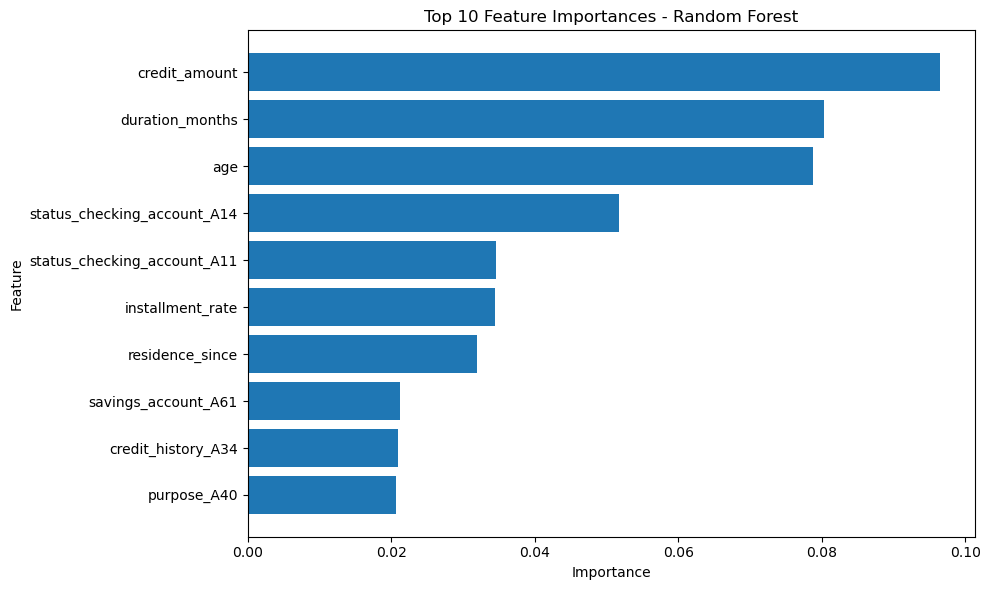

In [44]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.tight_layout()

plt.savefig(r"C:\Users\COMPUTER SERVIES BW\Documents\PhD_Projects\Decision-Focused-Loan-Approval-System/figures/feature_importance.png")

plt.show()

## 4.7 Feature Importance Interpretation

The Random Forest model identified credit amount, loan duration, and age as some of the strongest predictors of loan approval decisions.

These findings are economically plausible, as larger loan amounts and longer repayment durations are naturally associated with increased financial risk.

The prominence of demographic-related variables such as age also highlights the importance of fairness-aware analysis in financial machine learning systems. While such features may improve predictive performance, they may also introduce potential biases or disparate impacts across applicant groups.

Overall, the feature importance analysis demonstrates that explainability methods can provide valuable insight into how machine learning systems make high-stakes financial decisions.

## 4.8 SHAP explanation

#### 4.8.1 Importing SHAP

In [46]:
import shap

#### 4.8.2 Transforming test data

In [47]:
X_test_processed = rf_model.named_steps[
    "preprocessor"
].transform(X_test)

#### 4.8.3 Creating SHAP explainer

In [48]:
explainer = shap.TreeExplainer(
    rf_model.named_steps["classifier"]
)

#### 4.8.4 Computing SHAP values

In [49]:
shap_values = explainer.shap_values(X_test_processed)

#### 4.8.5 Global SHAP summary plot

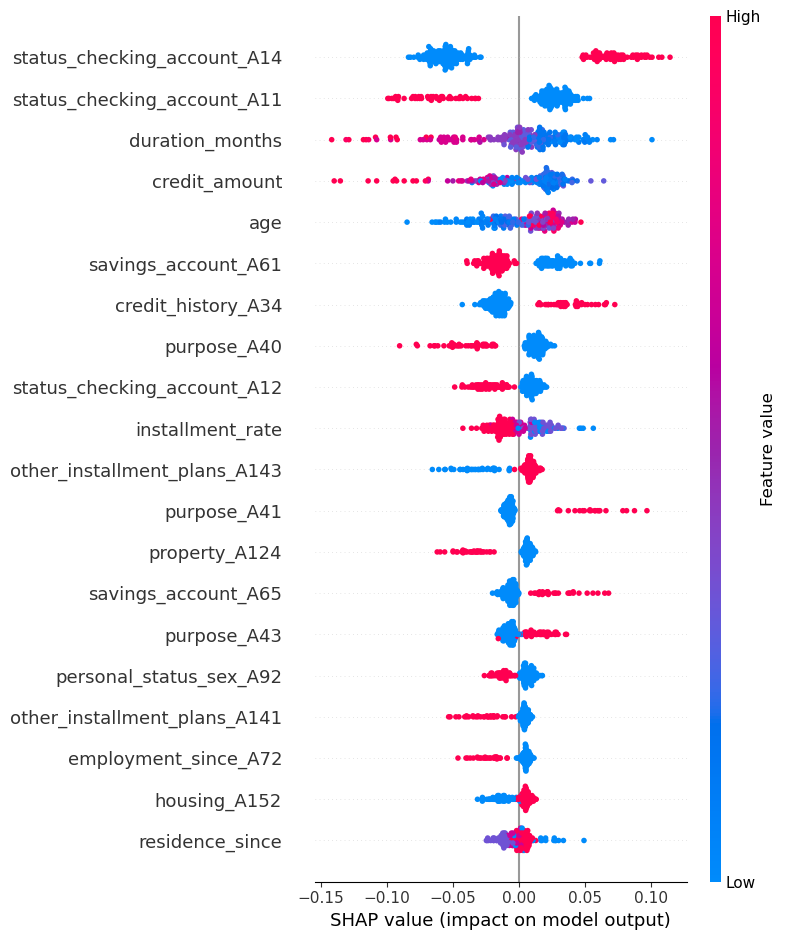

In [56]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_processed,
    feature_names=all_features,
    show=False
)

plt.tight_layout()

plt.savefig(r"C:\Users\COMPUTER SERVIES BW\Documents\PhD_Projects\Decision-Focused-Loan-Approval-System/figures/shap_summary.png")

plt.show()

#### 4.8.6 SHAP Explainability Analysis

SHAP analysis was used to examine how individual features influence loan approval predictions in the Random Forest model.

Unlike traditional feature importance measures, SHAP values provide local explanations for individual applicants by showing how specific features push predictions toward approval or rejection.

The analysis revealed that financial characteristics such as credit amount, loan duration, and checking account status exert substantial influence on model decisions. Furthermore, the variability of SHAP values across applicants suggests that different combinations of financial attributes contribute differently to decision outcomes.

These findings demonstrate the importance of explainable AI methods in high-stakes financial systems, where transparency and accountability are essential.

# LAYER 5: Causal Recourse

## 5.1 Finding rejected applicants

In [51]:
rejected_cases = full_analysis[
    full_analysis["RandomForest"] == 0
]

rejected_cases.head()

,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,housing,number_credits,job,people_liable,telephone,foreign_worker,Actual,LogisticRegression,RandomForest,Disagreement
1,A12,36,A31,A44,3990,A65,A72,3,A92,A101,...,A152,1,A171,1,A191,A201,1,0,0,False
13,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A153,1,A173,1,A192,A201,0,0,0,False
25,A14,48,A34,A46,6110,A61,A73,1,A93,A101,...,A153,1,A173,1,A192,A201,1,1,0,True
27,A12,18,A32,A41,12976,A61,A71,3,A92,A101,...,A153,1,A174,1,A192,A201,0,1,0,True
29,A12,36,A32,A40,14318,A61,A75,4,A93,A101,...,A153,1,A174,1,A192,A201,0,0,0,False


## 5.2 Selecting one applicant

In [52]:
applicant = X_test.iloc[[0]].copy()

applicant

,status_checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker
977,A12,18,A33,A49,2427,A65,A75,4,A93,A101,2,A122,42,A143,A152,2,A173,1,A191,A201


## 5.3 Predicting approval probability

In [53]:
rf_model.predict_proba(applicant)

array([[0.135, 0.865]])

#### 5.3.1 Interpretation of prediction

--> 13.5% rejection probability.\
--> 86.5% approval probability.

## 5.4 Simulating improvement

In [54]:
modified_applicant = applicant.copy()

modified_applicant["credit_amount"] = (
    modified_applicant["credit_amount"] * 0.7
)

## 5.5 Re-predict

In [55]:
rf_model.predict_proba(modified_applicant)

array([[0.16, 0.84]])

#### 5.5.1 Interpretation of prediction¶

--> 16.0% rejection probability.\
--> 84.0% approval probability.

## 5.6 Comparison of results

A simple recourse experiment was conducted by reducing the applicant's requested credit amount by 30% and re-evaluating the approval probability using the Random Forest model.

Interestingly, the approval probability decreased slightly from 86.5% to 84.0%, demonstrating that changes to a single feature do not always lead to intuitive outcomes in nonlinear machine learning systems.

This result highlights an important challenge in recourse analysis: machine learning models often capture complex interactions between variables, meaning that actionable recommendations must account for broader causal relationships rather than isolated feature changes alone.

These findings motivate the need for causal recourse methods capable of generating realistic and reliable recommendations in high-stakes financial decision systems.

# LAYER 6: Conclusion

This project explored machine learning approaches for financial loan approval systems using the German Credit dataset.

Multiple predictive models, including Logistic Regression and Random Forest classifiers, were developed and evaluated. Although the models achieved comparable predictive performance, disagreement analysis revealed that they produced different decisions for a subset of applicants, illustrating the phenomenon of model multiplicity.

Explainability techniques such as feature importance analysis and SHAP values were used to better understand the factors driving model decisions. In addition, initial recourse experiments demonstrated that nonlinear machine learning systems may respond unexpectedly to isolated feature changes, motivating the need for more advanced causal recourse methods.

Overall, the project highlights the importance of transparency, explainability, and decision robustness in high-stakes financial machine learning systems.